# Практическая работа №4. Регрессионная модель

**ФИО:** Райымбердиев Исхак  
**Уровень:** B (данные заданы)  
**Датасет:** Auto MPG — расход топлива автомобилей (`mpg`, мили на галлон).  
**Цель:** построить линейную регрессию, сравнить наборы признаков, корректно оценить качество на тестовой выборке.

Связь с лекцией: МНК, метрики MAE / MSE / RMSE / R².  
Предобработка — пайплайн по образцу ПР-3: `ColumnTransformer` + `Pipeline`, обучение только на train.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
RANDOM_STATE = 42
TEST_SIZE = 0.2

Matplotlib is building the font cache; this may take a moment.


## 1. Загрузка и первичный осмотр данных

Целевая переменная — `mpg` (miles per gallon). Чем больше значение, тем экономичнее автомобиль.  
`car name` — текстовый идентификатор, в числовую модель не входит.  
`horsepower` в файле записан как строка: пропуски закодированы символом `?`.

In [2]:
df = pd.read_csv("data/auto-mpg.csv")
print("Размер:", df.shape)
df.head()

Размер: (398, 9)


,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino


In [3]:
print(df.dtypes)
print("\nПропуски (NaN):")
print(df.isna().sum())
print("\nЗнаков '?' в horsepower:", (df["horsepower"] == "?").sum())
print("\nЦелевая переменная mpg:")
print(df["mpg"].describe())

mpg             float64
cylinders         int64
displacement    float64
horsepower       object
weight            int64
acceleration    float64
model year        int64
origin            int64
car name         object
dtype: object

Пропуски (NaN):
mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model year      0
origin          0
car name        0
dtype: int64

Знаков '?' в horsepower: 6

Целевая переменная mpg:
count    398.000000
mean      23.514573
std        7.815984
min        9.000000
25%       17.500000
50%       23.000000
75%       29.000000
max       46.600000
Name: mpg, dtype: float64


In [4]:
df["horsepower"] = pd.to_numeric(df["horsepower"], errors="coerce")
print("Пропусков в horsepower после преобразования:", df["horsepower"].isna().sum())

df = df.drop(columns=["car name"])
df.head()

Пропусков в horsepower после преобразования: 6


,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin
0,18.0,8,307.0,130.0,3504,12.0,70,1
1,15.0,8,350.0,165.0,3693,11.5,70,1
2,18.0,8,318.0,150.0,3436,11.0,70,1
3,16.0,8,304.0,150.0,3433,12.0,70,1
4,17.0,8,302.0,140.0,3449,10.5,70,1


## 2. Разделение на train / test

Разделение делается **до** заполнения пропусков и масштабирования, чтобы не было утечки из теста.

In [5]:
target = "mpg"
all_numeric_features = [
    "cylinders",
    "displacement",
    "horsepower",
    "weight",
    "acceleration",
    "model year",
    "origin",
]

X = df[all_numeric_features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
)

print("Train:", X_train.shape, "Test:", X_test.shape)
print("Средний mpg на train: {:.2f}, на test: {:.2f}".format(y_train.mean(), y_test.mean()))

Train: (318, 7) Test: (80, 7)
Средний mpg на train: 23.61, на test: 23.14


## 3. Пайплайн предобработки (аналог ПР-3)

Для числовых признаков:
1. `SimpleImputer(strategy="median")` — устойчивее среднего к выбросам (`horsepower` имеет 6 пропусков).
2. `StandardScaler` — приводит признаки к одному масштабу. Это нужно градиентному спуску/устойчивости МНК при разных единицах (фунты vs куб. дюймы vs годы), но **коэффициенты после масштабирования нельзя читать как «+1 фунт → Δ mpg»**.

In [6]:
def make_preprocessor(feature_names):
    numeric_pipeline = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])
    preprocessor = ColumnTransformer(
        transformers=[("num", numeric_pipeline, list(feature_names))],
        remainder="drop",
    )
    return preprocessor


def make_model(feature_names):
    return Pipeline(steps=[
        ("preprocessor", make_preprocessor(feature_names)),
        ("regressor", LinearRegression()),
    ])

## 4. Метрики и правило интерпретации

| Метрика | Единицы | Смысл |
|---|---|---|
| **MAE** | mpg | средняя абсолютная ошибка: на сколько миль/галлон мы ошибаемся в типичном случае |
| **RMSE** | mpg | как MAE, но сильнее штрафует крупные ошибки |
| **MSE** | mpg² | квадрат ошибки; **нельзя напрямую сравнивать с MAE** |
| **R²** | безразмерный | доля объяснённой дисперсии; смотрим **на тесте**, на train он всегда завышен |

Качество модели оцениваем по **тестовой** выборке.

In [7]:
def regression_metrics(y_true, y_pred, split_name):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    return {
        "split": split_name,
        "MAE_mpg": mae,
        "RMSE_mpg": rmse,
        "MSE_mpg2": mse,
        "R2": r2,
    }


def evaluate_feature_set(feature_names, label):
    model = make_model(feature_names)
    model.fit(X_train[feature_names], y_train)

    y_tr = model.predict(X_train[feature_names])
    y_te = model.predict(X_test[feature_names])

    rows = [
        {"model": label, **regression_metrics(y_train, y_tr, "train")},
        {"model": label, **regression_metrics(y_test, y_te, "test")},
    ]
    coefs = model.named_steps["regressor"].coef_
    intercept = model.named_steps["regressor"].intercept_
    return model, pd.DataFrame(rows), coefs, intercept, y_te

## 5. Базовая модель: все доступные числовые признаки

In [8]:
base_model, base_metrics, base_coefs, base_intercept, y_pred_base = evaluate_feature_set(
    all_numeric_features, "все числовые признаки"
)
base_metrics

,model,split,MAE_mpg,RMSE_mpg,MSE_mpg2,R2
0,все числовые признаки,train,2.598758,3.414649,11.659828,0.814027
1,все числовые признаки,test,2.255644,2.863241,8.198151,0.847523


In [9]:
print("Свободный член (после масштабирования, на среднем масштабе признаков): {:.3f} mpg".format(base_intercept))
coef_base = pd.Series(base_coefs, index=all_numeric_features).sort_values(key=np.abs, ascending=False)
print("\nКоэффициенты — изменение mpg при росте признака на 1 стандартное отклонение (train):")
print(coef_base.round(4))

test_row = base_metrics.query("split == 'test'").iloc[0]
print("\nИнтерпретация на ТЕСТЕ:")
print(
    "MAE = {:.3f} mpg: в среднем модель ошибается примерно на {:.2f} мили на галлон ".format(
        test_row["MAE_mpg"], test_row["MAE_mpg"]
    )
    + "(средний mpg на тесте ≈ {:.1f}).".format(y_test.mean())
)
print(
    "RMSE = {:.3f} mpg: типичная ошибка с учётом крупных промахов; ".format(test_row["RMSE_mpg"])
    + "это всё ещё мили/галлон, в отличие от MSE."
)
print(
    "MSE = {:.3f} (mpg)² — квадрат ошибки, по шкале несравним с MAE.".format(test_row["MSE_mpg2"])
)
print(
    "R²_test = {:.3f}: модель объясняет {:.1f}% дисперсии mpg на отложенных данных. ".format(
        test_row["R2"], 100 * test_row["R2"]
    )
    + "R²_train смотреть как «качество модели» нельзя — он завышен."
)

Свободный член (после масштабирования, на среднем масштабе признаков): 23.608 mpg

Коэффициенты — изменение mpg при росте признака на 1 стандартное отклонение (train):
weight         -5.6591
model year      2.8591
displacement    1.4651
origin          1.0732
horsepower     -0.4949
cylinders      -0.2643
acceleration    0.1876
dtype: float64

Интерпретация на ТЕСТЕ:
MAE = 2.256 mpg: в среднем модель ошибается примерно на 2.26 мили на галлон (средний mpg на тесте ≈ 23.1).
RMSE = 2.863 mpg: типичная ошибка с учётом крупных промахов; это всё ещё мили/галлон, в отличие от MSE.
MSE = 8.198 (mpg)² — квадрат ошибки, по шкале несравним с MAE.
R²_test = 0.848: модель объясняет 84.8% дисперсии mpg на отложенных данных. R²_train смотреть как «качество модели» нельзя — он завышен.


## 6. Мультиколлинеарность: корреляции и VIF

VIF считаем **только по train**, после той же импутации, что в пайплайне, но **без** StandardScaler: VIF от линейного масштаба не зависит, а интерпретировать удобнее в исходных единицах.  
Правило: VIF > 10 — сильная линейная зависимость, признак-кандидат на удаление.

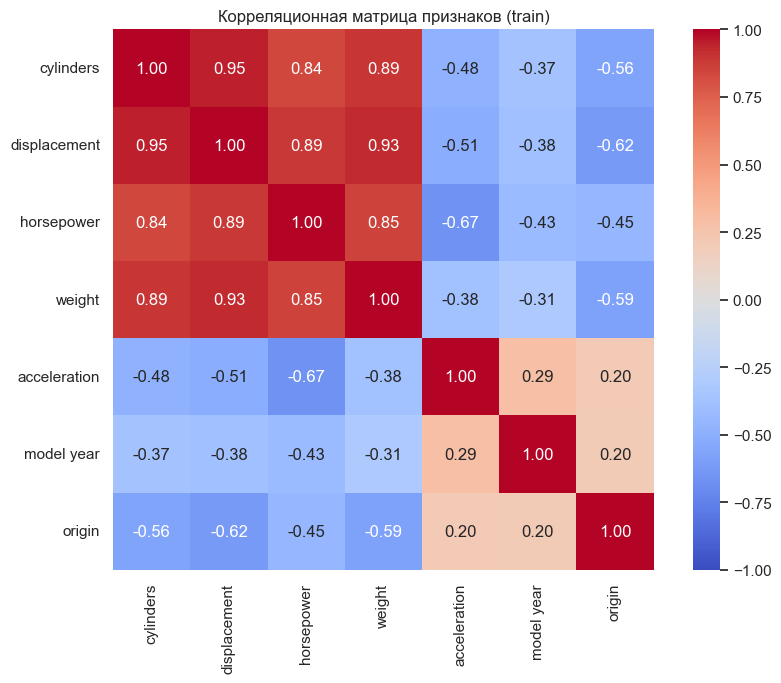

Пара признаков с |r| > 0.8:
               a             b         r
0      cylinders  displacement  0.951825
7   displacement        weight  0.929479
2      cylinders        weight  0.893808
6   displacement    horsepower  0.887484
11    horsepower        weight  0.852840
1      cylinders    horsepower  0.837799


In [10]:
imputer = SimpleImputer(strategy="median")
X_train_imp = pd.DataFrame(
    imputer.fit_transform(X_train[all_numeric_features]),
    columns=all_numeric_features,
    index=X_train.index,
)

corr = X_train_imp.corr()
plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, square=True)
plt.title("Корреляционная матрица признаков (train)")
plt.tight_layout()
plt.show()

print("Пара признаков с |r| > 0.8:")
pairs = (
    corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    .stack()
    .reset_index()
)
pairs.columns = ["a", "b", "r"]
print(pairs.loc[pairs["r"].abs() > 0.8].sort_values("r", key=np.abs, ascending=False))

In [11]:
def compute_vif(frame):
    design = add_constant(frame, has_constant="add")
    vif = pd.DataFrame({"feature": frame.columns})
    vif["VIF"] = [
        variance_inflation_factor(design.values, i)
        for i in range(1, design.shape[1])
    ]
    return vif.sort_values("VIF", ascending=False).reset_index(drop=True)


print("VIF, полный набор:")
print(compute_vif(X_train_imp).round(2))

VIF, полный набор:
        feature    VIF
0  displacement  21.75
1     cylinders  11.02
2        weight  10.30
3    horsepower   9.12
4  acceleration   2.50
5        origin   1.81
6    model year   1.27


`cylinders`, `displacement`, `horsepower` и `weight` описывают почти одно и то же: размер/мощность двигателя и массу. Оставляем `weight` — он напрямую связан с расходом и обычно даёт самый устойчивый сигнал. `horsepower` частично дублирует массу/объём, его тоже убираем при высоком VIF.

`origin` кодирует регион числами 1/2/3: как непрерывный признак это грубо, но в задании базовый набор — все числовые колонки. В сокращённом наборе оставляем `origin`, `model year` и `acceleration` как относительно независимые факторы.

In [12]:
reduced_features = ["weight", "model year", "origin", "acceleration"]
print("VIF, сокращённый набор:")
print(compute_vif(X_train_imp[reduced_features]).round(2))

VIF, сокращённый набор:
        feature   VIF
0        weight  1.76
1        origin  1.52
2  acceleration  1.21
3    model year  1.15


## 7. Сравнение нескольких наборов признаков

1. **База** — все числовые признаки.  
2. **Сокращённый (VIF)** — `weight`, `model year`, `origin`, `acceleration`.  
3. **Минимальный** — только `weight` и `model year` (самые интерпретируемые драйверы расхода).  
4. **Без года** — проверка, насколько важен технический прогресс (`model year`).

In [13]:
feature_sets = {
    "все числовые признаки": all_numeric_features,
    "сокращённый (VIF)": reduced_features,
    "минимальный: weight + year": ["weight", "model year"],
    "без года: weight + origin + acceleration": ["weight", "origin", "acceleration"],
}

all_metrics = []
models = {}
test_preds = {}

for name, feats in feature_sets.items():
    model, metrics, coefs, intercept, y_te = evaluate_feature_set(feats, name)
    models[name] = (model, coefs, intercept, feats)
    test_preds[name] = y_te
    all_metrics.append(metrics)

comparison = pd.concat(all_metrics, ignore_index=True)
comparison_rounded = comparison.copy()
for col in ["MAE_mpg", "RMSE_mpg", "MSE_mpg2", "R2"]:
    comparison_rounded[col] = comparison_rounded[col].round(4)
comparison_rounded

,model,split,MAE_mpg,RMSE_mpg,MSE_mpg2,R2
0,все числовые признаки,train,2.5988,3.4146,11.6598,0.8140
1,все числовые признаки,test,2.2556,2.8632,8.1982,0.8475
2,сокращённый (VIF),train,2.5919,3.4345,11.7956,0.8119
3,сокращённый (VIF),test,2.2573,2.9140,8.4917,0.8421
4,минимальный: weight + year,train,2.6910,3.5102,12.3213,0.8035
5,минимальный: weight + year,test,2.4463,3.0725,9.4406,0.8244
6,без года: weight + origin + acceleration,train,3.3199,4.3310,18.7577,0.7008
7,без года: weight + origin + acceleration,test,2.9703,3.7150,13.8015,0.7433


In [14]:
test_cmp = comparison.query("split == 'test'").sort_values("RMSE_mpg")
print("Ранжирование по RMSE на тесте (меньше — лучше):")
print(test_cmp[["model", "MAE_mpg", "RMSE_mpg", "R2"]].to_string(index=False))

print("\nРазница train vs test по R² (диагностика переобучения):")
pivot = comparison.pivot(index="model", columns="split", values="R2")
pivot["gap"] = pivot["train"] - pivot["test"]
print(pivot.round(4))

Ранжирование по RMSE на тесте (меньше — лучше):
                                   model  MAE_mpg  RMSE_mpg       R2
                   все числовые признаки 2.255644  2.863241 0.847523
                       сокращённый (VIF) 2.257273  2.914047 0.842064
              минимальный: weight + year 2.446334  3.072549 0.824415
без года: weight + origin + acceleration 2.970350  3.715040 0.743306

Разница train vs test по R² (диагностика переобучения):
split                                       test   train     gap
model                                                           
без года: weight + origin + acceleration  0.7433  0.7008 -0.0425
все числовые признаки                     0.8475  0.8140 -0.0335
минимальный: weight + year                0.8244  0.8035 -0.0209
сокращённый (VIF)                         0.8421  0.8119 -0.0302


## 8. Сокращённая модель: коэффициенты (с учётом масштабирования)

In [15]:
final_name = "сокращённый (VIF)"
final_model, final_coefs, final_intercept, final_feats = models[final_name]
y_pred_final = test_preds[final_name]

print("Интерсепт (ожидаемый mpg при нулевых стандартизованных признаках): {:.3f}".format(final_intercept))
coef_final = pd.Series(final_coefs, index=final_feats).sort_values(key=np.abs, ascending=False)
print(coef_final.round(4))
print(
    "\nЧитать так: коэффициент — это Δmpg, если признак вырос на 1 σ обучающей выборки, "
    "а остальные стандартизованные признаки фиксированы. Это не «плюс один фунт веса»."
)

Интерсепт (ожидаемый mpg при нулевых стандартизованных признаках): 23.608
weight         -5.0871
model year      2.8312
origin          0.8818
acceleration    0.1597
dtype: float64

Читать так: коэффициент — это Δmpg, если признак вырос на 1 σ обучающей выборки, а остальные стандартизованные признаки фиксированы. Это не «плюс один фунт веса».


## 9. Графики: предсказание vs истина и остатки

Систематический паттерн в остатках (дуга, «воронка», кластеры) говорит, что линейная модель в исходных признаках не полностью соответствует данным: нелинейность, гетероскедастичность и т.д.

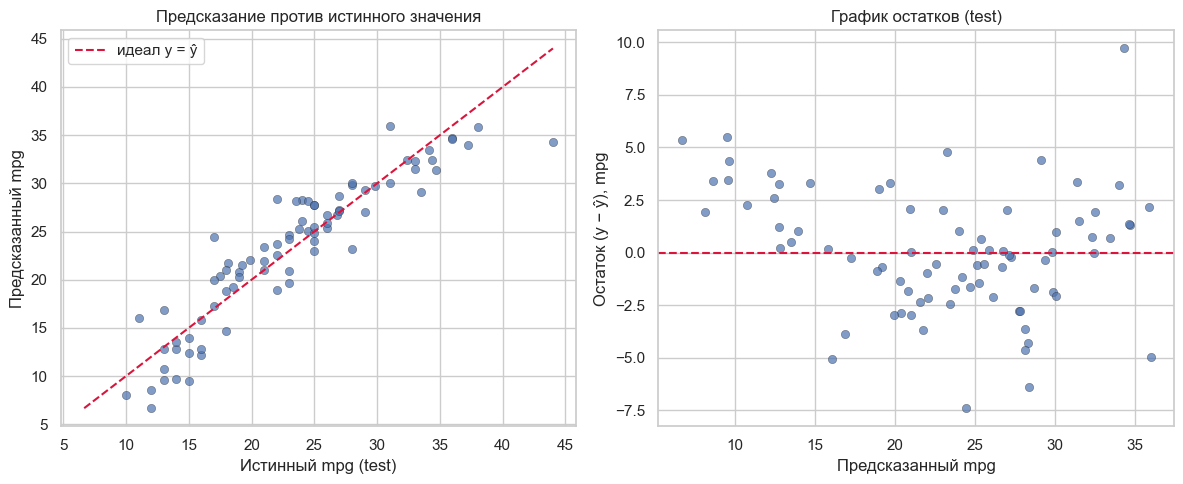

Средний остаток: 0.064 mpg (смещение)
Стд. остатков: 2.932 mpg
Корреляция остатков с предсказанием: -0.224


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

lo = min(y_test.min(), y_pred_final.min())
hi = max(y_test.max(), y_pred_final.max())

axes[0].scatter(y_test, y_pred_final, alpha=0.7, edgecolor="k", linewidth=0.3)
axes[0].plot([lo, hi], [lo, hi], color="crimson", linestyle="--", label="идеал y = ŷ")
axes[0].set_xlabel("Истинный mpg (test)")
axes[0].set_ylabel("Предсказанный mpg")
axes[0].set_title("Предсказание против истинного значения")
axes[0].legend()

residuals = y_test.to_numpy() - y_pred_final
axes[1].scatter(y_pred_final, residuals, alpha=0.7, edgecolor="k", linewidth=0.3)
axes[1].axhline(0, color="crimson", linestyle="--")
axes[1].set_xlabel("Предсказанный mpg")
axes[1].set_ylabel("Остаток (y − ŷ), mpg")
axes[1].set_title("График остатков (test)")

plt.tight_layout()
plt.show()

print("Средний остаток: {:.3f} mpg (смещение)".format(residuals.mean()))
print("Стд. остатков: {:.3f} mpg".format(residuals.std(ddof=1)))
print("Корреляция остатков с предсказанием: {:.3f}".format(np.corrcoef(y_pred_final, residuals)[0, 1]))

## 10. Вывод о финальном наборе признаков

1. Базовая модель на всех 7 числовых признаках на **тесте**: MAE ≈ 2.26 mpg, RMSE ≈ 2.86 mpg, R² ≈ 0.85. Средний расход на тесте около 23 mpg, то есть типичная ошибка — примерно 10% среднего. R² на train (0.81) не используем как оценку качества: он может быть как выше, так и ниже теста на маленькой выборке, но в любом случае не заменяет hold-out.
2. VIF полного набора: `displacement` 21.8, `cylinders` 11.0, `weight` 10.3, `horsepower` 9.1. Это одна «двигатель–масса» группа. После сокращения до `weight`, `model year`, `origin`, `acceleration` все VIF < 2. MAE на тесте почти не меняется (2.257 vs 2.256 mpg), RMSE чуть хуже (2.91 vs 2.86). Отброшенные признаки почти не добавляли новой информации, зато ломали интерпретацию коэффициентов (у `displacement` в полной модели даже положительный знак).
3. Без `model year` RMSE на тесте растёт до 3.72 mpg, R² падает до 0.74 — год выпуска нужен: более новые машины экономичнее при той же массе.
4. Пара `weight + model year` уже даёт MAE 2.45 mpg. `origin` и `acceleration` добавляют немного, при этом остаются ортогональнее двигателя. Для уровня B берём **сокращённый набор**.
5. Остатки почти не смещены (среднее 0.06 mpg), но корреляция с предсказанием ≈ −0.22: видна лёгкая воронка/изгиб. Линейность и гомоскедастичность соблюдены нестрого; модель полезна как интерпретируемая база, не как «идеальный» прогноз.
6. **Итог:** финальная модель — `LinearRegression` в пайплайне (медиана + StandardScaler) на `weight`, `model year`, `origin`, `acceleration`. Коэффициенты читаем в mpg на 1 σ признака, не в исходных фунтах. Сравниваем MAE и RMSE (обе в mpg); MSE = 8.5 (mpg)² с ними не сопоставляем.